## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this second laboratory we will gain some experience working with Transformer models for a variety tasks using (mostly) the Hugging Face Ecosystem. 


---
### Exercise 1: Sentiment Analysis (warm up)

In this first exercise we will start from a pre-trained BERT transformer and build up a model able to perform text sentiment analysis. Transformers are complex beasts, so we will build up our pipeline in several explorative and incremental steps.

#### Exercise 1.1: Loading the Dataset Splits
There are a many sentiment analysis datasets, but we will use one of the smallest ones available: the [Cornell Rotten Tomatoes movie review dataset](https://huggingface.co/datasets/cornell-movie-review-data/rotten_tomatoes), which consists of 5,331 positive and 5,331 negative processed sentences from the Rotten Tomatoes movie reviews.

**Your first task**: Load the dataset and figure out what splits are available and how to get them. Spend some time exploring the dataset to see how it is organized. Note that we will be using the [HuggingFace Datasets](https://huggingface.co/docs/datasets/en/index) library for downloading, accessing, splitting, and batching data for training and evaluation.

In [1]:
# Dataset imports.
from datasets import load_dataset, get_dataset_split_names
# load scarica il datasate
# get_dataset_split_names mi dice quali split ci sono (train, validation e test)

# Your code here.
splits = get_dataset_split_names('cornell-movie-review-data/rotten_tomatoes')

c:\Users\checc\anaconda3\envs\DLA2026-transformers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load all splits into dict.
ds_dict = {split: load_dataset('cornell-movie-review-data/rotten_tomatoes', split=split) for split in splits}

In [3]:
ds_dict

{'train': Dataset({
     features: ['text', 'label'],
     num_rows: 8530
 }),
 'validation': Dataset({
     features: ['text', 'label'],
     num_rows: 1066
 }),
 'test': Dataset({
     features: ['text', 'label'],
     num_rows: 1066
 })}

In [4]:
import numpy as np

ds_train = ds_dict['train']
for row in np.random.permutation(len(ds_train))[:10]:
    print(f'{ds_train[row]['label']}: {ds_train[row]['text']}')
# estraggo alcuni esempi, 1 positivo e 0 negativo

0: [u]nrelentingly stupid .
1: a startling and fresh examination of how the bike still remains an ambiguous icon in chinese society .
1: narc is a no-bull throwback to 1970s action films . it zips along with b-movie verve while adding the rich details and go-for-broke acting that heralds something special .
0: [a] mess .
1: there are times when a rumor of angels plays like an extended episode of touched by an angel -- a little too much dancing , a few too many weeping scenes -- but i liked its heart and its spirit .
1: the cast is top-notch and i predict there will be plenty of female audience members drooling over michael idemoto as michael .
0: fairly successful at faking some pretty cool stunts but a complete failure at trying to create some pretty cool characters . and forget about any attempt at a plot !
0: confirms the nagging suspicion that ethan hawke would be even worse behind the camera than he is in front of it .
1: a meditation on faith and madness , frailty is blood-curdli


---
### Exercise 1.2: A Pre-trained BERT and Tokenizer

The model we will use is a *very* small BERT transformer called [DistilBERT](https://huggingface.co/distilbert/distilbert-base-uncased) this model was trained (using self-supervised learning) on the same corpus as BERT but using the full BERT base model as a *teacher*.

**Your next task**: Load the DistilBERT model and corresponding tokenizer. Use the tokenizer on a few samples from the dataset and pass the tokens through the model to see what outputs are provided. I suggest you use the [`AutoModel`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html) class (and the `from_pretrained()` method) to load the model and `AutoTokenizer` to load the tokenizer).

In [5]:
# AutoClass imports.
from transformers import AutoTokenizer, AutoModel

# Your code here.
# caricare questi due modelli (andare a vedere distilBERT per capire meglio)

model = AutoModel.from_pretrained('distilbert/distilbert-base-uncased')
# associare il tokenizer al modello
tokenizer = AutoTokenizer.from_pretrained('distilbert/distilbert-base-uncased')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1758.47it/s]
DistilBertModel LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
tokens = tokenizer.encode('This is a sample sentence', return_tensors='pt')
# pt è pytorch, tf è tensorflow, è un modo per restituire un tensore
#encode è per tokenizzare


In [7]:
tokens

tensor([[ 101, 2023, 2003, 1037, 7099, 6251,  102]])

In [8]:
tokenizer.decode(tokens)
# decode è il contrario di encode, serve per convertire i token in parole
# non è sensibile alle maiuscole/minuscole
# CLS class token 

['[CLS] this is a sample sentence [SEP]']

In [9]:
tokens

tensor([[ 101, 2023, 2003, 1037, 7099, 6251,  102]])

In [10]:
model
# prima calcola l'embedding, 6 trasformer box.
# abbiamo 7 token in output
# Noterai che ci sono 6 blocchi (layer). BERT Base originale ne ha 12 DistilBERT è una versione "distillata", più piccola e veloce, ma che mantiene la stessa dimensione nascosta (768) e lo stesso numero di teste di attenzione (12) per ogni blocco

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [11]:
output = model(tokens)

In [12]:
output
# restituisce l'ultimo layer

BaseModelOutput(last_hidden_state=tensor([[[-0.2760, -0.2467,  0.0496,  ..., -0.0402,  0.0381,  0.5147],
         [-0.7048, -0.5992, -0.1607,  ..., -0.2416,  0.2256,  0.4610],
         [-0.5693, -0.3484,  0.0569,  ..., -0.1084, -0.1021,  1.0647],
         ...,
         [ 0.2166, -0.3616, -0.1386,  ..., -0.3729, -0.0196, -0.0457],
         [-0.0907, -0.2729, -0.2289,  ..., -0.1412, -0.2120, -0.1424],
         [ 0.9912, -0.0259, -0.4097,  ...,  0.2881, -0.8304, -0.1778]]],
       grad_fn=<NativeLayerNormBackward0>), hidden_states=None, attentions=None)

In [13]:
output.last_hidden_state[0][0].shape
# 7 token, 768 dimensioni
# ogni parola (token) nella tua frase è stata "masticata" dal modello e trasformata in un vettore di 768 numeri che ne cattura il significato semantico e sintattico in base alle altre parole presenti nella frase

torch.Size([768])

In [14]:
batch = tokenizer(ds_train[:2]['text'], return_tensors='pt', padding=True)
# padding true sarebbe zeroper fare in modo che abbiamo sempre la stessa lunghezza di token

In [15]:
batch

{'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102,     0,     0,     0,
             0,     0],
        [  101,  1996,  9882,  2135,  9603, 13633,  1997,  1000,  1996,  2935,
          1997,  1996,  7635,  1000, 11544,  2003,  2061,  4121,  2008,  1037,
          5930,  1997,  2616,  3685, 23613,  6235,  2522,  1011,  3213,  1013,
          2472,  2848,  4027,  1005,  1055,  4423,  4432,  1997,  1046,  1012,
          1054,  1012,  1054,  1012, 23602,  1005,  1055,  2690,  1011,  3011,
          1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [16]:
tokenizer.decode(batch['input_ids'])

['[CLS] the rock is destined to be the 21st century \' s new " conan " and that he \' s going to make a splash even greater than arnold schwarzenegger, jean - claud van damme or steven segal. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD]',
 '[CLS] the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co - writer / director peter jackson \' s expanded vision of j. r. r. tolkien \' s middle - earth. [SEP]']

In [17]:
no_masking = model.forward(input_ids=batch['input_ids']).last_hidden_state
masking = model.forward(input_ids=batch['input_ids'], attention_mask=batch['attention_mask']).last_hidden_state

# no_masking i padding token contribuiscono al calcolo dell'output
# masking i padding token non contribuiscono al calcolo dell'output

In [18]:
masking

tensor([[[-0.0332, -0.0168,  0.0194,  ...,  0.0476,  0.5834,  0.3036],
         [-0.0235, -0.0555, -0.3638,  ...,  0.1877,  0.5781, -0.1577],
         [-0.0516, -0.1014, -0.1511,  ...,  0.1503,  0.2649, -0.1575],
         ...,
         [ 0.3688, -0.1147,  0.8428,  ..., -0.0708, -0.0178, -0.2516],
         [ 0.0654, -0.0206,  0.1889,  ...,  0.1159,  0.2323, -0.2404],
         [ 0.0373, -0.0104,  0.1203,  ...,  0.1049,  0.2852, -0.3035]],

        [[-0.2062, -0.0490, -0.4036,  ..., -0.1186,  0.6141,  0.3919],
         [-0.4361, -0.1647, -0.3533,  ...,  0.1086,  0.9478, -0.0272],
         [-0.1164,  0.1690,  0.2698,  ..., -0.1971,  0.4372,  0.2527],
         ...,
         [-0.2341,  0.4810, -0.2634,  ..., -0.3397,  0.2567,  0.1274],
         [ 0.7139,  0.0574, -0.3260,  ...,  0.2041, -0.3800, -0.3343],
         [ 0.5649,  0.2806, -0.0295,  ...,  0.1297, -0.3160, -0.1874]]],
       grad_fn=<NativeLayerNormBackward0>)

In [19]:
batch.keys()
# dizionario con chiavi

KeysView({'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102,     0,     0,     0,
             0,     0],
        [  101,  1996,  9882,  2135,  9603, 13633,  1997,  1000,  1996,  2935,
          1997,  1996,  7635,  1000, 11544,  2003,  2061,  4121,  2008,  1037,
          5930,  1997,  2616,  3685, 23613,  6235,  2522,  1011,  3213,  1013,
          2472,  2848,  4027,  1005,  1055,  4423,  4432,  1997,  1046,  1012,
          1054,  1012,  1054,  1012, 23602,  1005,  1055,  2690,  1011,  3011,
          1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [20]:
masking = model.forward(**batch)


---
### Exercise 1.3: A Stable Baseline

In this exercise I want you to:
1. Use DistilBERT as a *feature extractor* to extract representations of the text strings from the dataset splits;
2. Train a classifier (your choice, by an SVM from Scikit-learn is an easy choice).
3. Evaluate performance on the validation and test splits.

These results are our *stable baseline* -- the **starting** point on which we will (hopefully) improve in the next exercise.

**Hint**: There are a number of ways to implement the feature extractor, but probably the best is to use a [feature extraction `pipeline`](https://huggingface.co/tasks/feature-extraction). You will need to interpret the output of the pipeline and extract only the `[CLS]` token from the *last* transformer layer. *How can you figure out which output that is?*

In [21]:
ds_train['text']

Column(['the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson\'s expanded vision of j . r . r . tolkien\'s middle-earth .', 'effective but too-tepid biopic', 'if you sometimes like to go to the movies to have fun , wasabi is a good place to start .', "emerges as something rare , an issue movie that's so honest and keenly observed that it doesn't feel like one .", ...])

In [22]:
from transformers import pipeline
import torch
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Your code here.
extractor = pipeline('feature-extraction', model=model, tokenizer=tokenizer)
feats = extractor(list(ds_train['text']), return_tensors='pt') # estrazione del token CLS

# converto in una lista la colonna text del dataset



In [23]:
feats = torch.vstack([feat[0][0] for feat in feats])
# ogni prompt è rappresentato da un vettore di 768 elementi cioè un tensore
# abbiamo estratto tutti i class token

In [24]:
feats.shape

torch.Size([8530, 768])

---
---
## Exercise 2: Fine-tuning DistilBERT

In this exercise we will fine-tune the DistilBERT model to (hopefully) improve sentiment analysis performance.


---
### Exercise 2.1: Token Preprocessing

The first thing we need to do is *tokenize* our dataset splits -- we don't want to re-tokenize our inputs for every batch! Our current datasets return a dictionary with *strings*, but we want *input token ids* (i.e. the output of the tokenizer). This is easy enough to do by hand, but the Hugging Face `Dataset` class provides convenient, efficient, and *lazy* methods. See the documentation for [`Dataset.map`](https://huggingface.co/docs/datasets/v3.5.0/en/package_reference/main_classes#datasets.Dataset.map).

**Tip**: Verify that your new datasets are returning for every element: `text`, `label`, `intput_ids`, and `attention_mask`.

In [25]:
# Your code here.
def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True) # funzione che vuole tokenizzare

# viene troncata perché c'è un limite fisico di 512 token
# map è una funzione che applica una funzione a tutti gli elementi del dataset
# Dataset maps are NOT performed in-place!
tokenized_train = ds_train.map(preprocess_function, batched=True) # restituisce un nuovo data-set
tokenized_train.set_format('pt', columns=['input_ids'], output_all_columns=True) # settare il formato di questa colonna a pytorch tensor

In [ ]:
# Tokenizza tutto il dizionario dei dataset
tokenized_datasets = {
    split: ds.map(preprocess_function, batched=True) 
    for split, ds in ds_dict.items()
}

# Poi assegna le variabili singole se preferisci usarle così
tokenized_train = tokenized_datasets['train']
tokenized_val = tokenized_datasets['validation']
tokenized_test = tokenized_datasets['test']

# Imposta il formato per tutti
for split in tokenized_datasets:
    tokenized_datasets[split].set_format('pt', columns=['input_ids', 'attention_mask'], output_all_columns=True)


In [48]:
ds_train

Dataset({
    features: ['text', 'label'],
    num_rows: 8530
})

In [49]:
tokenized_train
# abbiamo aggiunto imput_ids, token_type_ids, attention_mask per creare i batch

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8530
})

In [50]:
tokenized_train['input_ids'] # ho dei tensori

Column([tensor([  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
         1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
         1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
        29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
         4168,  2030,  7112, 16562,  2140,  1012,   102]), tensor([  101,  1996,  9882,  2135,  9603, 13633,  1997,  1000,  1996,  2935,
         1997,  1996,  7635,  1000, 11544,  2003,  2061,  4121,  2008,  1037,
         5930,  1997,  2616,  3685, 23613,  6235,  2522,  1011,  3213,  1013,
         2472,  2848,  4027,  1005,  1055,  4423,  4432,  1997,  1046,  1012,
         1054,  1012,  1054,  1012, 23602,  1005,  1055,  2690,  1011,  3011,
         1012,   102]), tensor([  101,  4621,  2021,  2205,  1011,  8915, 23267, 16012, 24330,   102]), tensor([  101,  2065,  2017,  2823,  2066,  2000,  2175,  2000,  1996,  5691,
         2000,  2031,  4569,  1010,  2001, 28518,


---
### Exercise 2.2: Setting up the Model to be Fine-tuned

In this exercise we need to prepare the base Distilbert model for fine-tuning for a *sequence classification task*. This means, at the very least, appending a new, randomly-initialized classification head connected to the `[CLS]` token of the last transformer layer. Luckily, HuggingFace already provides an `AutoModel` for just this type of instantiation: [`AutoModelForSequenceClassification`](https://huggingface.co/transformers/v3.0.2/model_doc/auto.html#automodelforsequenceclassification). You will want you instantiate one of these for fine-tuning.

In [51]:
model

DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [52]:
from transformers import AutoModelForSequenceClassification, DistilBertForSequenceClassification
# quando crea l'istanza del modello, il classificatore viene inizializzato con pesi casuali
# numero di etichette = 2

# Your code here.
cls_model = DistilBertForSequenceClassification.from_pretrained('distilbert/distilbert-base-uncased', num_labels=2) 

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8356.85it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [53]:
cls_model
# presuppone di avere 512 token in input

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [54]:
tokenizer(ds_train[0]['text'], padding='max_length', max_length=512)

{'input_ids': [101, 1996, 2600, 2003, 16036, 2000, 2022, 1996, 7398, 2301, 1005, 1055, 2047, 1000, 16608, 1000, 1998, 2008, 2002, 1005, 1055, 2183, 2000, 2191, 1037, 17624, 2130, 3618, 2084, 7779, 29058, 8625, 13327, 1010, 3744, 1011, 18856, 19513, 3158, 5477, 4168, 2030, 7112, 16562, 2140, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [55]:
tokens

{'input_ids': tensor([[  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
          1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
          1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
         29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
          4168,  2030,  7112, 16562,  2140,  1012,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,  

In [56]:
# Example output for DistilBERT classification model.
tokens = tokenizer(ds_train[0]['text'], return_tensors='pt', padding='max_length', max_length=512)
cls_model.forward(tokens['input_ids'])

# output del modello sono i logits

SequenceClassifierOutput(loss=None, logits=tensor([[0.1174, 0.0386]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)


---
### Exercise 2.3: Fine-tuning DistilBERT

Finally. In this exercise you should use a HuggingFace [`Trainer`](https://huggingface.co/docs/transformers/main/en/trainer) to fine-tune your model on the Rotten Tomatoes training split. Setting up the trainer will involve (at least):


1. Instantiating a [`DataCollatorWithPadding`](https://huggingface.co/docs/transformers/en/main_classes/data_collator) object which is what *actually* does your batch construction (by padding all sequences to the same length).
2. Writing an *evaluation function* that will measure the classification accuracy. This function takes a single argument which is a tuple containing `(logits, labels)` which you should use to compute classification accuracy (and maybe other metrics like F1 score, precision, recall) and return a `dict` with these metrics.  
3. Instantiating a [`TrainingArguments`](https://huggingface.co/docs/transformers/v4.51.1/en/main_classes/trainer#transformers.TrainingArguments) object using some reasonable defaults.
4. Instantiating a `Trainer` object using your train and validation splits, you data collator, and function to compute performance metrics.
5. Calling `trainer.train()`, waiting, waiting some more, and then calling `trainer.evaluate()` to see how it did.

**Tip**: When prototyping this laboratory I discovered the HuggingFace [Evaluate library](https://huggingface.co/docs/evaluate/en/index) which provides evaluation metrics. However I found it to have insufferable layers of abstraction and getting actual metrics computed. I suggest just using the Scikit-learn metrics...

In [34]:
# ci pensa la classe trainer a imparare, in imput si danno il learning rate e il numero di epoche

In [57]:
tokenized_train[0]['input_ids']

tensor([  101,  1996,  2600,  2003, 16036,  2000,  2022,  1996,  7398,  2301,
         1005,  1055,  2047,  1000, 16608,  1000,  1998,  2008,  2002,  1005,
         1055,  2183,  2000,  2191,  1037, 17624,  2130,  3618,  2084,  7779,
        29058,  8625, 13327,  1010,  3744,  1011, 18856, 19513,  3158,  5477,
         4168,  2030,  7112, 16562,  2140,  1012,   102])

In [58]:
tokenized_train[2]['input_ids']

tensor([  101,  4621,  2021,  2205,  1011,  8915, 23267, 16012, 24330,   102])

In [36]:
# non sono della stessa lunghezza e non possiamo fare un batch.
# data collator si occupa di fare il batch e di fare il padding.
# in imput dobbiamo fornire il tokenizar che sa già tutto

In [37]:
!pip install "accelerate>=1.1.0"


In [38]:
!pip install transformers[torch] -U


In [39]:
# Your code here.
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# wandb.login() mettere la chiave

training_args = TrainingArguments(
    output_dir='./output',
    learning_rate=2e-5, # più basso (da rimettere giusto)
    per_device_train_batch_size=48,
    per_device_eval_batch_size=48,
    num_train_epochs=5,
    use_cpu=False,
#    save_strategy='epoch',
#    report_to='wandb',
    logging_strategy="steps",
    logging_steps=50,
#    do_eval=True,
#    eval_strategy='epoch'
)

trainer = Trainer(
   model=cls_model,
   args=training_args,
   train_dataset=tokenized_train,
   data_collator=data_collator,
#   eval_dataset=tokenized_val,
#   compute_metrics=compute_metrics,
)

trainer.train()

Step,Training Loss
50,0.552693
100,0.415581
150,0.395640
200,0.343661
250,0.266251
300,0.291165
350,0.282955
400,0.194126
450,0.198549
500,0.194077


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s]


TrainOutput(global_step=890, training_loss=0.23151112352864125, metrics={'train_runtime': 393.3153, 'train_samples_per_second': 108.437, 'train_steps_per_second': 2.263, 'total_flos': 602696134289016.0, 'train_loss': 0.23151112352864125, 'epoch': 5.0})

In [50]:
from transformers import DistilBertForSequenceClassification, Trainer

# Definiamo una funzione che restituisce una nuova istanza del modello
# Questo assicura che ogni chiamata a train() riparta dai pesi pre-addestrati puliti [2]
def model_init():
    return DistilBertForSequenceClassification.from_pretrained(
        'distilbert/distilbert-base-uncased', 
        num_labels=2
    )

# 2. Definizione dei parametri di training (Ottimizzati)
training_args = TrainingArguments(
    output_dir='./output',
    learning_rate=2e-5,               # Valore standard consigliato dal paper BERT [3, 4]
    per_device_train_batch_size=32,   # 32 è più stabile di 48 per dataset piccoli [3]
    per_device_eval_batch_size=32,
    num_train_epochs=3,               # 3 epoche sono spesso sufficienti; 5 potrebbero causare overfitting [3, 4]
    weight_decay=0.01,                # Aggiunge regolarizzazione per migliorare la generalizzazione [5]
    logging_strategy="steps",
    logging_steps=50,                 # Logging ogni 50 step per un output più pulito su antigravity [6]
    eval_strategy="epoch",            # Valuta alla fine di ogni epoca [2]
    save_strategy="epoch",            # Salva un checkpoint a ogni epoca [6]
    load_best_model_at_end=True,      # Carica automaticamente il miglior modello trovato durante la validazione [7]
    report_to="none"                  # Disabilita WandB se non necessario [8]
)

# Quando inizializziamo il Trainer, usiamo model_init invece dell'argomento model [1]
trainer = Trainer(
   args=training_args,
   train_dataset=tokenized_train,
   eval_dataset=tokenized_val,
   data_collator=data_collator,
   model_init=model_init  # <--- Il Trainer chiamerà questa funzione per ogni run [2]
)

# Ora puoi chiamare train() più volte e il modello si resetterà sempre automaticamente
trainer.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2799.02it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1663.88it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-unca

Epoch,Training Loss,Validation Loss
1,0.358092,0.362810
2,0.263722,0.358037
3,0.183156,0.390197


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.01it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=801, training_loss=0.2948451213138678, metrics={'train_runtime': 237.9703, 'train_samples_per_second': 107.534, 'train_steps_per_second': 3.366, 'total_flos': 348266105180592.0, 'train_loss': 0.2948451213138678, 'epoch': 3.0})

In [56]:
from transformers import TrainingArguments, Trainer

def model_init():
    return DistilBertForSequenceClassification.from_pretrained(
        'distilbert/distilbert-base-uncased', 
        num_labels=2
    )

training_args_improved = TrainingArguments(
    output_dir='./output_improved',
    learning_rate=3e-5,               # Valore alternativo raccomandato [8, 10]
    per_device_train_batch_size=16,   # Batch più piccolo per generalizzare meglio [7, 10]
    per_device_eval_batch_size=16,
    num_train_epochs=4,               # BERT consiglia tra 2 e 4 epoche [8]
    weight_decay=0.1,                 # Regolarizzazione più forte per contrastare l'overfitting [13, 15]
    warmup_ratio=0.1,                 # 10% degli step dedicati al warmup del learning rate [12, 13]
    logging_strategy="steps",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,      # Fondamentale per recuperare l'epoca prima del degrado [16]
    report_to="none"
)

# Puoi usare la stessa funzione model_init() definita sopra
trainer_improved = Trainer(
   args=training_args_improved,
   train_dataset=tokenized_train,
   eval_dataset=tokenized_val,
   data_collator=data_collator,
   model_init=model_init 
)

trainer_improved.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1393.48it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1303.56it/s]
D

Epoch,Training Loss,Validation Loss
1,0.382883,0.364471
2,0.265457,0.378674
3,0.140577,0.608362
4,0.047081,0.703641


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.06it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2136, training_loss=0.22120279804820872, metrics={'train_runtime': 357.449, 'train_samples_per_second': 95.454, 'train_steps_per_second': 5.976, 'total_flos': 430650995579880.0, 'train_loss': 0.22120279804820872, 'epoch': 4.0})

In [ ]:
from transformers import TrainingArguments, Trainer, DistilBertForSequenceClassification
import math

# 1. Funzione di inizializzazione per ripartire sempre da pesi puliti
def model_init():
    return DistilBertForSequenceClassification.from_pretrained(
        'distilbert/distilbert-base-uncased', 
        num_labels=2
    )

# 2. Calcolo manuale dei warmup_steps
# Dataset: 8530 esempi / Batch: 32 = ~267 step per epoca.
num_epochs = 3
total_steps = math.ceil(len(tokenized_train) / 32) * num_epochs
warmup_steps_val = math.ceil(total_steps * 0.1)

# 3. Configurazione dei parametri migliori basata sui test 1 e 2
training_args_final = TrainingArguments(
    output_dir='./output_final',
    learning_rate=2e-5,               # Valore più stabile dal paper BERT [4]
    per_device_train_batch_size=32,   # Bilanciamento ottimale trovato nei tuoi run
    per_device_eval_batch_size=32,
    num_train_epochs=3,               # Ridotto a 3 per fermarsi prima dell'overfitting visto nei log
    weight_decay=0.1,                 # Aumentato per contrastare l'overfitting aggressivo
    warmup_steps=warmup_steps_val,    # Sostituisce warmup_ratio
    logging_strategy="steps",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,      # Recupera il miglior checkpoint (probabilmente epoca 1 o 2)
    report_to="none"
)

# 4. Inizializzazione del Trainer con model_init
trainer_final = Trainer(
   args=training_args_final,
   train_dataset=tokenized_train,
   eval_dataset=tokenized_val,
   data_collator=data_collator,
   model_init=model_init            # Garantisce che il modello parta da zero ogni volta
)

# 5. Esecuzione e valutazione
trainer_final.train()
final_results = trainer_final.evaluate()


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1823.59it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1454.69it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-unca

Epoch,Training Loss,Validation Loss
1,0.358306,0.364424
2,0.269674,0.354593
3,0.172954,0.387855


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.97it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


RuntimeError: on_train_begin must be called before on_evaluate

In [40]:
!pip install evaluate


In [74]:
# Creazione del dataset di test tokenizzato (partendo dallo split 'test' del tuo dizionario)
tokenized_test = ds_dict['test'].map(preprocess_function, batched=True)
tokenized_test.set_format('pt', columns=['input_ids', 'attention_mask', 'label'], output_all_columns=True)


In [63]:
from transformers import DataCollatorWithPadding, DistilBertForSequenceClassification
import evaluate
import numpy as np
import math
from transformers import EarlyStoppingCallback


# 1. Definizione del data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 2. Definizione della funzione per le metriche (accuracy e f1)
metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="binary")["f1"]
    return {"accuracy": acc, "f1": f1}

# 3. Definizione del model_init
def model_init():
    return DistilBertForSequenceClassification.from_pretrained(
        'distilbert/distilbert-base-uncased', 
        num_labels=2
    )


# --- Warmup: 10% degli step totali ---
num_epochs = 3
batch_size = 32
total_steps = math.ceil(len(tokenized_train) / batch_size) * num_epochs
warmup_steps_val = math.ceil(total_steps * 0.1)

training_args_exp4 = TrainingArguments(
    output_dir='./output_exp4',

    # Parametri di learning stabili (confermati da Exp1 e Exp3)
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,          # 4 epoche ma con early stopping

    # Regolarizzazione (confermata da Exp3)
    weight_decay=0.1,
    warmup_steps=warmup_steps_val,

    # Novità 1: cosine scheduler — decade più dolcemente verso la fine
    # evita che il lr resti troppo alto nelle ultime epoche
    lr_scheduler_type="cosine",

    # Novità 2: metrica esplicita per scegliere il best checkpoint
    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,

    # Novità 3: early stopping — si ferma se val_loss non migliora per 2 epoche
    # Risolve il problema "satura all'epoca 2 ma continua inutilmente"
    # (richiede EarlyStoppingCallback sotto)

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    report_to="none",
    disable_tqdm=True
)

trainer_exp4 = Trainer(
    args=training_args_exp4,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,      # Finalmente misuriamo accuracy e F1
    model_init=model_init,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    # patience=2: se per 2 epoche consecutive val_loss non scende, stop
)

trainer_exp4.train()

# Valutazione finale esplicita
results = trainer_exp4.evaluate(tokenized_test)
print(f"Test Accuracy : {results['eval_accuracy']:.4f}")
print(f"Test F1       : {results['eval_f1']:.4f}")
print(f"Test Loss     : {results['eval_loss']:.4f}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1990.70it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5663.31it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-unca

{'loss': '0.6893', 'grad_norm': '0.8649', 'learning_rate': '1.21e-05', 'epoch': '0.1873'}
{'loss': '0.5405', 'grad_norm': '6.995', 'learning_rate': '1.997e-05', 'epoch': '0.3745'}
{'loss': '0.4298', 'grad_norm': '5.03', 'learning_rate': '1.956e-05', 'epoch': '0.5618'}
{'loss': '0.3906', 'grad_norm': '3.461', 'learning_rate': '1.87e-05', 'epoch': '0.7491'}
{'loss': '0.3575', 'grad_norm': '4.016', 'learning_rate': '1.743e-05', 'epoch': '0.9363'}
{'eval_loss': '0.3694', 'eval_accuracy': '0.8368', 'eval_f1': '0.8441', 'eval_runtime': '2.938', 'eval_samples_per_second': '362.9', 'eval_steps_per_second': '11.57', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s]


{'loss': '0.3168', 'grad_norm': '4.684', 'learning_rate': '1.581e-05', 'epoch': '1.124'}
{'loss': '0.2575', 'grad_norm': '3.645', 'learning_rate': '1.391e-05', 'epoch': '1.311'}
{'loss': '0.2503', 'grad_norm': '9.342', 'learning_rate': '1.182e-05', 'epoch': '1.498'}
{'loss': '0.2766', 'grad_norm': '6.302', 'learning_rate': '9.651e-06', 'epoch': '1.685'}
{'loss': '0.2635', 'grad_norm': '4.872', 'learning_rate': '7.496e-06', 'epoch': '1.873'}
{'eval_loss': '0.3578', 'eval_accuracy': '0.8452', 'eval_f1': '0.8384', 'eval_runtime': '2.961', 'eval_samples_per_second': '360', 'eval_steps_per_second': '11.48', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.92it/s]


{'loss': '0.247', 'grad_norm': '5.816', 'learning_rate': '5.46e-06', 'epoch': '2.06'}
{'loss': '0.1633', 'grad_norm': '3.355', 'learning_rate': '3.639e-06', 'epoch': '2.247'}
{'loss': '0.1851', 'grad_norm': '4.171', 'learning_rate': '2.12e-06', 'epoch': '2.434'}
{'loss': '0.161', 'grad_norm': '4.311', 'learning_rate': '9.741e-07', 'epoch': '2.622'}
{'loss': '0.1928', 'grad_norm': '11.93', 'learning_rate': '2.563e-07', 'epoch': '2.809'}
{'loss': '0.1652', 'grad_norm': '4.113', 'learning_rate': '3.808e-10', 'epoch': '2.996'}
{'eval_loss': '0.3871', 'eval_accuracy': '0.8518', 'eval_f1': '0.8509', 'eval_runtime': '2.891', 'eval_samples_per_second': '368.7', 'eval_steps_per_second': '11.76', 'epoch': '3'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s]


{'train_runtime': '227.8', 'train_samples_per_second': '112.3', 'train_steps_per_second': '3.516', 'train_loss': '0.3052', 'epoch': '3'}


There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


{'eval_loss': '0.4391', 'eval_accuracy': '0.8443', 'eval_f1': '0.8428', 'eval_runtime': '2.844', 'eval_samples_per_second': '374.8', 'eval_steps_per_second': '11.96', 'epoch': '3'}
Test Accuracy : 0.8443
Test F1       : 0.8428
Test Loss     : 0.4391


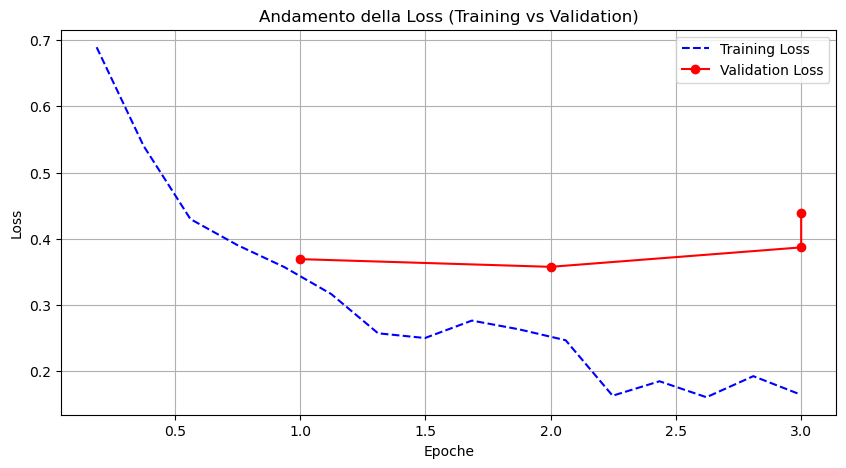

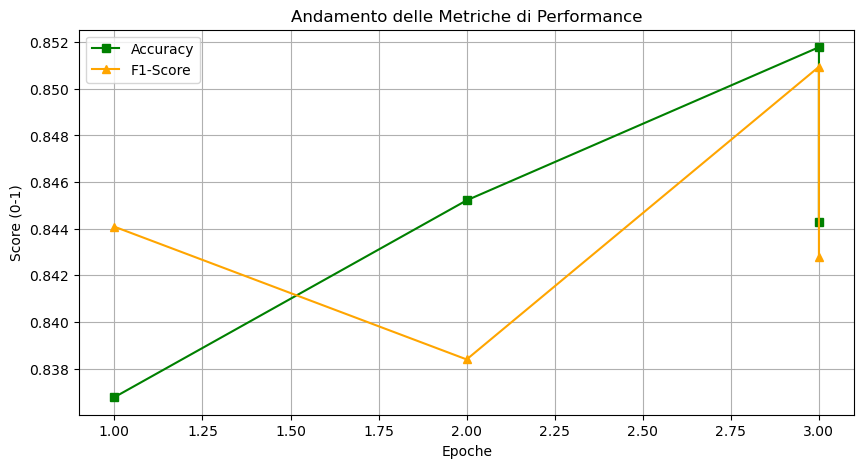

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# Estrazione della cronologia dei log
history = pd.DataFrame(trainer_exp4.state.log_history)

# Separiamo i log di training da quelli di valutazione
train_history = history[history['loss'].notna()]
eval_history = history[history['eval_loss'].notna()]

# --- Grafico 1: Loss ---
plt.figure(figsize=(10, 5))
plt.plot(train_history['epoch'], train_history['loss'], label='Training Loss', color='blue', linestyle='--')
plt.plot(eval_history['epoch'], eval_history['eval_loss'], label='Validation Loss', color='red', marker='o')
plt.title('Andamento della Loss (Training vs Validation)')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# --- Grafico 2: Accuratezza e F1 ---
plt.figure(figsize=(10, 5))
plt.plot(eval_history['epoch'], eval_history['eval_accuracy'], label='Accuracy', color='green', marker='s')
plt.plot(eval_history['epoch'], eval_history['eval_f1'], label='F1-Score', color='orange', marker='^')
plt.title('Andamento delle Metriche di Performance')
plt.xlabel('Epoche')
plt.ylabel('Score (0-1)')
plt.legend()
plt.grid(True)
plt.show()


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! Or if you want to propose something else as a third exercise, reach out to me on the Discord!


---
### Exercise 3.1: Efficient Fine-tuning for Sentiment Analysis (easy)

In Exercise 2 we fine-tuned the *entire* Distilbert model on Rotten Tomatoes. This is expensive, even for a small model. Find an *efficient* way to fine-tune Distilbert on the Rotten Tomatoes dataset (or some other dataset).

**Hint**: You could check out the [HuggingFace PEFT library](https://huggingface.co/docs/peft/en/index) for some state-of-the-art approaches that should "just work". How else might you go about making fine-tuning more efficient without having to change your training pipeline from above?

In [ ]:
# Your code here.
# dislbert è un modello ridotto di bert (pochi dati ma si rischia di overfittare)
# lora è una tecnica di fine-tuning
# tecniche di prompt learning


In [66]:
!pip install peft bitsandbytes accelerate


   ---------------------------------------- 0.0/557.0 kB ? eta -:--:--
   ---------------------------------------- 557.0/557.0 kB 14.6 MB/s  0:00:00
   ---------------------------------------- 0.0/55.4 MB ? eta -:--:--
   ---------- ----------------------------- 14.2/55.4 MB 67.9 MB/s eta 0:00:01
   ------------------------ --------------- 33.8/55.4 MB 79.4 MB/s eta 0:00:01
   ------------------------------- -------- 43.8/55.4 MB 68.4 MB/s eta 0:00:01
   ---------------------------------------- 55.4/55.4 MB 65.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [bitsandbytes]
   ---------------------------------------- 0/2 [bitsandbytes]
   ---------------------------------------- 0/2 [bitsandbytes]
   ---------------------------------------- 0/2 [bitsandbytes]
   ---------------------------------------- 0/2 [bitsandbytes]
   ---------------------------------------- 0/2 [bitsandbytes]
   -------------------- ------------------- 1/2 [peft]
   -------------------- ----------

In [69]:
model_id = 'distilbert/distilbert-base-uncased'

In [77]:
from transformers import Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType
import math

# Configurazione LoRA per compiti di classificazione [1, 3]
peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS, 
    r=8, 
    lora_alpha=16, 
    lora_dropout=0.1, 
    target_modules=["q_lin", "v_lin"] # Mira ai livelli di attenzione di DistilBERT
)

def peft_model_init():
    # Carichiamo una istanza pulita per ogni run per garantire riproducibilità [Regole.txt]
    base_model = DistilBertForSequenceClassification.from_pretrained(model_id, num_labels=2)
    return get_peft_model(base_model, peft_config)

# Calcolo parametri di training efficienti
num_epochs = 3
total_steps = math.ceil(len(tokenized_train) / 32) * num_epochs
warmup_steps_peft = math.ceil(total_steps * 0.1)

training_args_peft = TrainingArguments(
    output_dir="./output_peft_final",
    learning_rate=1e-3,              # LR più alto necessario per PEFT [3]
    per_device_train_batch_size=32,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    warmup_steps=warmup_steps_peft,
    lr_scheduler_type="cosine",      # Scheduler più dolce [4]
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none"
)

trainer_peft = Trainer(
    model_init=peft_model_init,
    args=training_args_peft,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer_peft.train()

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6918.55it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1604.59it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-unca

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.388207,0.828330,0.844520
2,0.393510,0.340523,0.843340,0.839885
3,0.393510,0.356461,0.843340,0.839269


TrainOutput(global_step=801, training_loss=0.34379570016849054, metrics={'train_runtime': 155.58, 'train_samples_per_second': 164.481, 'train_steps_per_second': 5.148, 'total_flos': 354239374467936.0, 'train_loss': 0.34379570016849054, 'epoch': 3.0})

In [78]:
# Importa il callback "problematico"
from transformers.utils.notebook import NotebookProgressCallback

# Rimuovilo dal trainer (usiamo try/except per comodità, nel caso in cui non fosse presente)
try:
    trainer_peft.remove_callback(NotebookProgressCallback)
except:
    pass

# Ora esegui la valutazione sul test set - questa volta non crasherà!
peft_test_results = trainer_peft.evaluate(tokenized_test)

# Stampa dei risultati in modo leggibile
print(f"PEFT Test Accuracy : {peft_test_results.get('eval_accuracy', 0):.4f}")
print(f"PEFT Test F1       : {peft_test_results.get('eval_f1', 0):.4f}")
print(f"PEFT Test Loss     : {peft_test_results.get('eval_loss', 0):.4f}")


PEFT Test Accuracy : 0.8386
PEFT Test F1       : 0.8349
PEFT Test Loss     : 0.3831


In [79]:
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
import math

# 1. Definizione del model_init con logica di Freezing
def partial_freezing_model_init():
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert/distilbert-base-uncased', 
        num_labels=2
    )
    
    # Congeliamo il backbone di embeddings
    for param in model.distilbert.embeddings.parameters():
        param.requires_grad = False
        
    # Congeliamo i primi 4 Transformer Layer (indice 0, 1, 2, 3)
    # DistilBERT ha 6 layer in totale (0-5)
    for layer in model.distilbert.transformer.layer[:4]:
        for param in layer.parameters():
            param.requires_grad = False
            
    return model

# 2. Calcolo warmup (stessi parametri Exp 4)
num_epochs = 3
batch_size = 32
total_steps = math.ceil(len(tokenized_train) / batch_size) * num_epochs
warmup_steps_val = math.ceil(total_steps * 0.1)

# 3. Configurazione TrainingArguments (Identici all'Esperimento 4)
training_args_freeze = TrainingArguments(
    output_dir='./output_partial_freeze',
    learning_rate=2e-5,               # LR standard per fine-tuning completo
    per_device_train_batch_size=batch_size,
    num_train_epochs=num_epochs,
    weight_decay=0.1,
    warmup_steps=warmup_steps_val,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

# 4. Inizializzazione del Trainer
trainer_freeze = Trainer(
    model_init=partial_freezing_model_init,
    args=training_args_freeze,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# 5. Addestramento
trainer_freeze.train()


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8888.31it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3803.15it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-unca

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.374971,0.832083,0.822597
2,0.440019,0.360011,0.836773,0.832692
3,0.440019,0.358620,0.833021,0.828846


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.91it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=801, training_loss=0.4041128456220496, metrics={'train_runtime': 121.697, 'train_samples_per_second': 210.276, 'train_steps_per_second': 6.582, 'total_flos': 348266105180592.0, 'train_loss': 0.4041128456220496, 'epoch': 3.0})

In [83]:
# Importa la classe del callback
from transformers.utils.notebook import NotebookProgressCallback

# Disattiviamo preventivamente il callback per i notebook per evitare il RuntimeError
try:
    trainer_freeze.remove_callback(NotebookProgressCallback)
except Exception:
    pass

# Valutazione finale
freeze_test_results = trainer_freeze.evaluate(tokenized_test)

# Calcolo parametri addestrabili per il report
trainable_params = sum(p.numel() for p in trainer_freeze.model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in trainer_freeze.model.parameters())
perc_trainable = (trainable_params / total_params) * 100

print(f"--- RISULTATI LAYER FREEZING ---")
print(f"Parametri Addestrabili: {trainable_params} ({perc_trainable:.2f}%)")

# Uso il .get() per sicurezza in caso la metrica non venga calcolata, evitando KeyError
print(f"Test Accuracy: {freeze_test_results.get('eval_accuracy', 0):.4f}")
print(f"Test F1 Score: {freeze_test_results.get('eval_f1', 0):.4f}")
print(f"Test Loss: {freeze_test_results.get('eval_loss', 0):.4f}")



--- RISULTATI LAYER FREEZING ---
Parametri Addestrabili: 14767874 (22.06%)
Test Accuracy: 0.8377
Test F1 Score: 0.8348
Test Loss: 0.3965



---
### Exercise 3.2: Fine-tuning a CLIP Model (harder)

Use a (small) CLIP model like [`openai/clip-vit-base-patch16`](https://huggingface.co/openai/clip-vit-base-patch16) and evaluate its zero-shot performance on a small image classification dataset like ImageNette or TinyImageNet. Fine-tune (using a parameter-efficient method!) the CLIP model to see how much improvement you can squeeze out of it.

**Note**: There are several ways to adapt the CLIP model; you could fine-tune the image encoder, the text encoder, or both. Or, you could experiment with prompt learning.

**Tip**: CLIP probably already works very well on ImageNet and ImageNet-like images. For extra fun, look for an image classification dataset with different image types (e.g. *sketches*).

In [ ]:
# Your code here.
# fine-tuning di un modello clip. si lavora sia con immagini che testo
# imageNet-Sketch sono immagini di oggetti disegnati a mano


---
### Exercise 3.3: A Text-to-image Retrieval System (hard, but not *too* hard)

Implement a simple text-to-image retrieval system with a simple user interface --- using, for example, [gradio](https://www.gradio.app/), or [Marimo](https://marimo.io/), or [Shiny](https://shiny.posit.co/). Your application should *index* (e.g. compute visual descriptors for) a small dataset of images like [Flickr8k](https://huggingface.co/datasets/jxie/flickr8k). It should provide a user interface with which a user can enter a short text prompt (e.g. "a photo of dogs playing in the snow") and then display the top-10 matching images from the indexed dataset.

Note that there is no following code block with "Your code here" for this exercise. You will definitely want to implement this outside of a Jupyter Notebook.

**Hint**: The **CLIP** model is practically *made* for just such an application.

---
---

In [ ]:
# meglio gradio
# creare un progetto per bene separato